In [4]:
import sqlite3
import pandas as pd

In [5]:
conn = sqlite3.connect('datadb.db')
cursor = conn.cursor()

In [6]:
# enable foreign key enforcement for SQLite connection
cursor.execute("PRAGMA foreign_keys = ON;")

In [7]:
# load data
products = pd.read_csv('/content/products_cleaned.csv', index_col=0)
sales = pd.read_csv('/content/sales_cleaned.csv', index_col=0)
stores = pd.read_csv('/content/stores_cleaned.csv', index_col=0)
exchange = pd.read_csv('/content/exchange_rates_cleaned.csv', index_col=0)
customers = pd.read_csv('/content/customers_cleaned.csv', index_col=0)

In [8]:
products.head()

,product_key,product_name,brand,color,unit_cost_usd,unit_price_usd,subcategory_key,subcategory,category_key,category,profit
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,6.62,12.99,101,MP4&MP3,1,Audio,6.37
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,6.62,12.99,101,MP4&MP3,1,Audio,6.37
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,7.40,14.52,101,MP4&MP3,1,Audio,7.12
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,11.00,21.57,101,MP4&MP3,1,Audio,10.57
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,11.00,21.57,101,MP4&MP3,1,Audio,10.57


In [9]:
# define table to store currency exchange rates
cursor.execute('''
CREATE TABLE IF NOT EXISTS exchange (
    date DATE,
    currency VARCHAR(3),
    exchange FLOAT,
    PRIMARY KEY (date, currency)
);
''')

In [10]:
# define table to store customers information
cursor.execute('''
CREATE TABLE IF NOT EXISTS customers (
  customer_key INT PRIMARY KEY,
  gender VARCHAR(255) NOT NULL,
  name VARCHAR(50) NOT NULL,
  city VARCHAR(50) NOT NULL,
  state_code VARCHAR(10),
  state VARCHAR(50),
  zip_code VARCHAR(10),
  country VARCHAR(50),
  continent VARCHAR(50),
  birthday DATE NOT NULL
  );
''')

In [11]:
# define table to store store information
cursor.execute('''
CREATE TABLE IF NOT EXISTS stores (
    store_key INTEGER PRIMARY KEY,
    country VARCHAR(20) NOT NULL,
    state VARCHAR(50) NOT NULL,
    square_meters FLOAT NOT NULL,
    open_date DATE NOT NULL
    );
''')

In [12]:
# define table to store sales information
cursor.execute("""
CREATE TABLE sales (
    order_number INT,
    line_item INT,
    order_date DATE,
    delivery_date DATE,
    customer_key INT,
    store_key INT,
    product_key INT,
    quantity INT,
    currency_code VARCHAR(3),
    PRIMARY KEY (order_number, line_item),
    FOREIGN KEY (customer_key) REFERENCES customers(customer_key),
    FOREIGN KEY (store_key) REFERENCES stores(store_key),
    FOREIGN KEY (product_key) REFERENCES products(product_key)
);
""")

In [13]:
# define table to store product details
cursor.execute('''
CREATE TABLE IF NOT EXISTS products (
    product_key INTEGER PRIMARY KEY,
    product_name VARCHAR(255) NOT NULL,
    brand VARCHAR(255) NOT NULL,
    color VARCHAR(255) NOT NULL,
    unit_cost_usd FLOAT NOT NULL,
    unit_price_usd FLOAT NOT NULL,
    subcategory_key INT NOT NULL,
    subcategory VARCHAR(255) NOT NULL,
    category_key INT NOT NULL,
    category VARCHAR(255),
    profit FLOAT
);
''')

In [14]:
# cursor.execute("DROP TABLE IF EXISTS products;")

In [15]:
# insert data into table
products.to_sql("products", conn, if_exists="append", index=False)

2517

In [16]:
stores.to_sql("stores", conn, if_exists="append", index=False)

67

In [17]:
customers.to_sql("customers", conn, if_exists="append", index=False)

15266

In [18]:
sales.to_sql("sales", conn, if_exists="append", index=False)

62884

In [19]:
exchange.to_sql("exchange", conn, if_exists="append", index=False)

11215

### Customer Analysis
-  demographic distribution : distribution of customers based on gender, age (from birthdate), location (city, state, country, continent)
- purchased patterns : identify purchasing patterns such as average order value, frequency of purchases, and preferred products

### Sales Analysis
- Overall sales performance : total sales over time, identifying trends and seasonality
- Sales by product : which products are the top performers based on quantity and revenue generated
- sales by store: assess the performance of difference storea based on sales data
- sales by currency : examine how different currencies impact sales figures, considering exchange rates

In [20]:
order_line = pd.read_sql("""
WITH order_cte AS(
  SELECT s.*, (p.unit_price_usd * s.quantity) as revenue, (p.unit_cost_usd * s.quantity) as cost
  FROM sales s
  JOIN products p ON s.product_key = p.product_key
)
SELECT
  o.order_number,
  SUM(o.quantity) as total_item,
  c.customer_key,
  CAST((julianday(o.order_date) - julianday(c.birthday))/365.25 AS INT) as age,
  o.order_date,
  SUM(o.revenue) as total_revenue,
  SUM(o.cost) as total_cost,
  SUM(o.revenue - o.cost) as total_profit,
  CASE
    WHEN o.store_key != 0 THEN 'Offline'
    ELSE 'Online'
  END AS store_type
FROM order_cte o
JOIN customers c ON o.order_number = c.customer_key
JOIN stores st ON o.store_key = st.store_key
GROUP BY o.order_date, o.order_number
ORDER BY o.order_date, o.order_number, total_revenue DESC
""", conn)
order_line

,order_number,total_item,customer_key,age,order_date,total_revenue,total_cost,total_profit,store_type
0,367004,5,367004,74,2016-01-02,421.91,194.01,227.90,Offline
1,378008,2,378008,63,2016-01-13,119.98,55.18,64.80,Offline
2,379002,7,379002,56,2016-01-14,3643.95,1241.50,2402.45,Online
3,391003,7,391003,73,2016-01-26,137.38,67.66,69.72,Offline
4,400009,2,400009,41,2016-02-04,218.00,72.22,145.78,Offline
...,...,...,...,...,...,...,...,...,...
160,1981004,8,1981004,71,2020-06-03,2376.88,1109.53,1267.35,Offline
161,1986003,4,1986003,74,2020-06-08,119.80,55.08,64.72,Offline
162,1998013,3,1998013,71,2020-06-20,43.70,22.27,21.43,Offline
163,2072003,1,2072003,27,2020-09-02,4.99,2.54,2.45,Online


In [21]:
order_line['order_date'] = pd.to_datetime(order_line['order_date'])

In [22]:
order_line.to_csv('order_line.csv', index=False)

What are the main drivers of revenue and profit growth across products and markets?

In [23]:
most_profit = pd.read_sql( """
SELECT p.product_name, SUM(s.quantity) as total_quantity,
SUM(s.quantity*p.profit) as total_profit
FROM products p
JOIN sales s ON p.product_key = s.product_key
GROUP BY p.product_name
ORDER BY total_profit DESC, total_quantity DESC
""", conn)
most_profit

,product_name,total_quantity,total_profit
0,WWI Desktop PC2.33 X2330 Black,550,337986.00
1,Adventure Works Desktop PC2.33 XD233 Silver,481,311663.95
2,Adventure Works Desktop PC2.33 XD233 Brown,479,310368.05
3,Adventure Works Desktop PC2.33 XD233 Black,462,299352.90
4,Adventure Works Desktop PC2.33 XD233 White,451,292225.45
...,...,...,...
2487,SV USB Data Cable E600 Pink,27,12.69
2488,SV USB Data Cable E600 Grey,23,10.81
2489,Litware 80mm Dual Ball Bearing Case Fan E1001 ...,4,9.80
2490,SV USB Sync Charge Cable E700 Silver,8,7.84


In [24]:
revenue_profit_year = pd.read_sql('''
SELECT
    strftime('%Y', s.order_date) AS year,
    p.category,
    SUM(s.quantity) AS total_quantity,
    SUM(s.quantity * p.unit_price_usd) AS total_revenue,
    SUM(s.quantity * (p.unit_price_usd - p.unit_cost_usd)) AS total_profit
FROM sales s
JOIN products p ON s.product_key = p.product_key
GROUP BY year,p.category
ORDER BY year DESC
''', conn)
revenue_profit_year

,year,category,total_quantity,total_revenue,total_profit
0,2021,Audio,323,43296.90,24814.49
1,2021,Cameras and camcorders,310,129196.99,77558.18
2,2021,Cell phones,738,159454.04,92113.39
3,2021,Computers,982,445745.65,261492.81
4,2021,Games and Toys,455,15155.18,8335.61
5,2021,Home Appliances,156,77082.06,45083.93
6,2021,"Music, Movies and Audio Books",587,67405.78,40480.79
7,2021,TV and Video,246,101951.88,58584.49
8,2020,Audio,3356,452725.55,261402.67
9,2020,Cameras and camcorders,3283,1209222.04,728723.98


In [25]:
import matplotlib.pyplot as plt

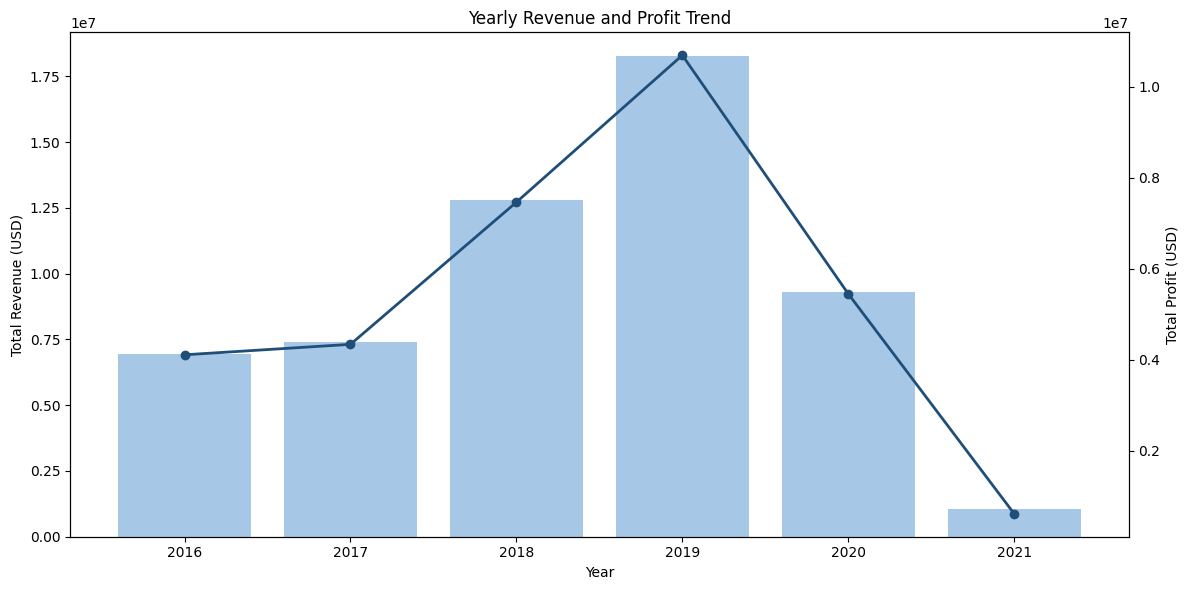

In [26]:
yearly = revenue_profit_year.groupby('year')[['total_revenue','total_profit']].sum().reset_index()

fig, ax1 = plt.subplots(figsize=(12,6))

# bar untuk Revenue (soft blue)
ax1.bar(yearly['year'], yearly['total_revenue'],
        color='#A7C7E7', label='Revenue')

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Revenue (USD)')
ax1.set_title('Yearly Revenue and Profit Trend')

# secondary axis untuk Profit (dark blue)
ax2 = ax1.twinx()
ax2.plot(yearly['year'], yearly['total_profit'],
         marker='o',
         linewidth=2,
         color='#1F4E79',
         label='Profit')

ax2.set_ylabel('Total Profit (USD)')

plt.tight_layout()
plt.show()


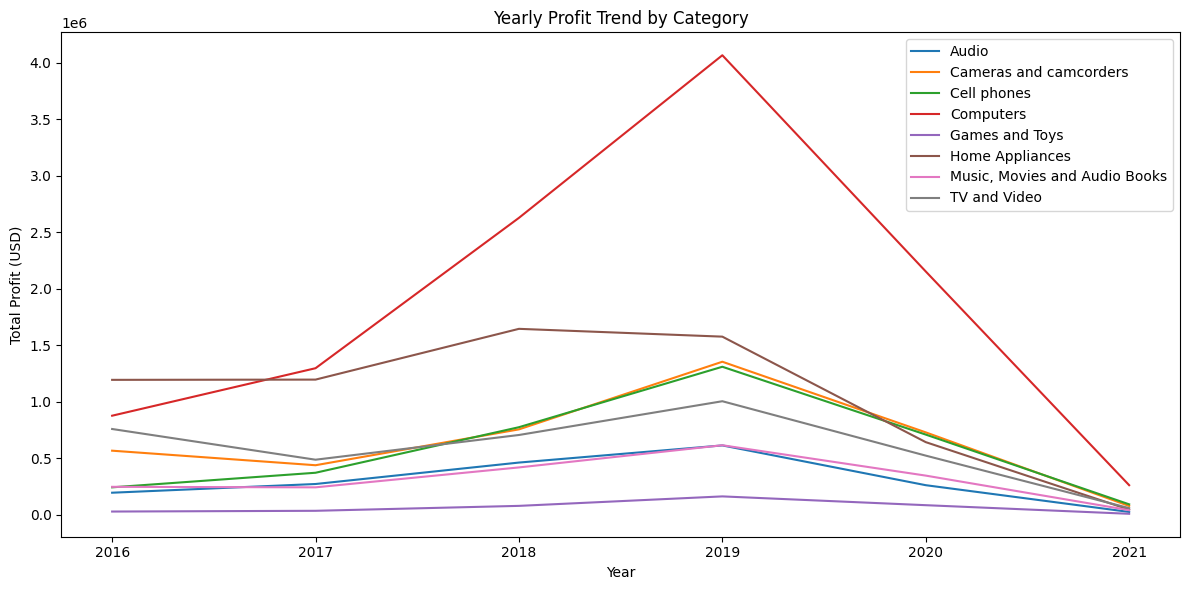

In [27]:
pivot_df = revenue_profit_year.pivot(
    index='year',
    columns='category',
    values='total_profit'
)

# mengurutkan berdasarkan waktu (ascending)
pivot_df = pivot_df.sort_index()

plt.figure(figsize=(12,6))

for col in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[col], label=col)

plt.title('Yearly Profit Trend by Category')
plt.xlabel('Year')
plt.ylabel('Total Profit (USD)')
plt.legend()
plt.tight_layout()
plt.show()

How does sales performance evolve over time, including seasonal trends and patterns?

In [28]:
revenue_profit = pd.read_sql('''
SELECT
    strftime('%m', s.order_date) AS month,
    p.category,
    SUM(s.quantity * p.unit_price_usd) AS revenue
FROM sales s
JOIN products p
    ON s.product_key = p.product_key
GROUP BY month, p.category
ORDER BY month, p.category
''', conn)
revenue_profit

,month,category,revenue
0,01,Audio,394556.77
1,01,Cameras and camcorders,893107.37
2,01,Cell phones,771546.12
3,01,Computers,2212613.88
4,01,Games and Toys,87371.97
...,...,...,...
91,12,Computers,2603411.45
92,12,Games and Toys,90518.46
93,12,Home Appliances,1410829.67
94,12,"Music, Movies and Audio Books",457499.63


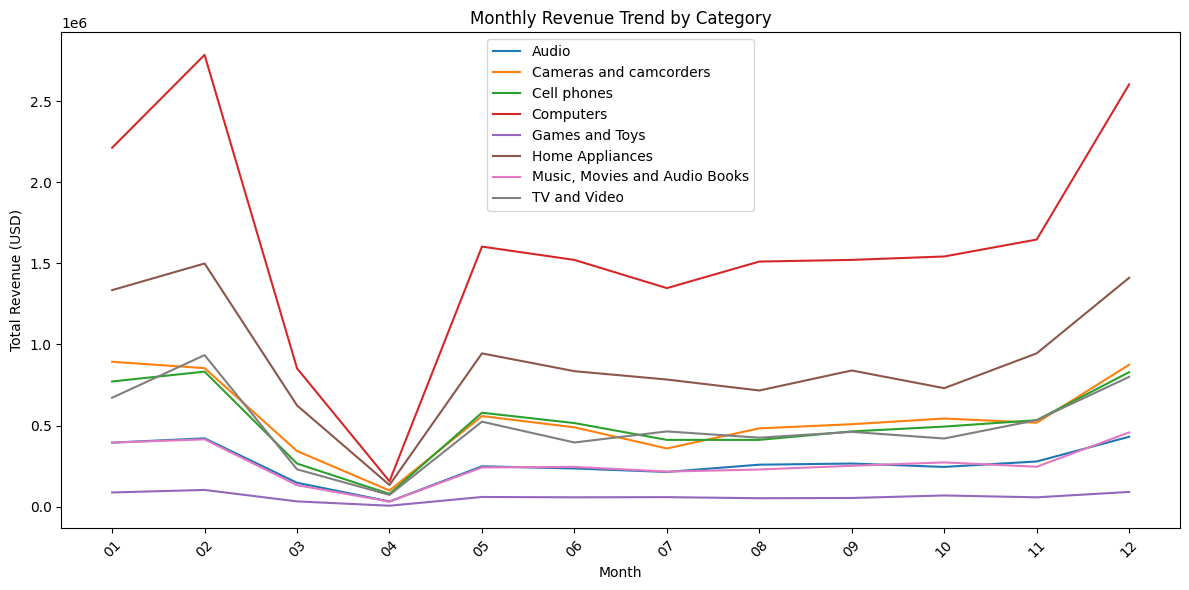

In [29]:
# membuat pivot data
pivot_df = revenue_profit.pivot(
    index='month',
    columns='category',
    values='revenue'
)

# mengurutkan berdasarkan waktu (ascending)
pivot_df = pivot_df.sort_index()

plt.figure(figsize=(12,6))

for col in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[col], label=col)

plt.title('Monthly Revenue Trend by Category')
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [30]:
revenue_profit_ym = pd.read_sql('''
SELECT
    strftime('%Y-%m', s.order_date) AS year_month,
    p.category,
    SUM(s.quantity * p.unit_price_usd) AS revenue
FROM sales s
JOIN products p
    ON s.product_key = p.product_key
GROUP BY year_month, p.category
ORDER BY year_month, p.category
''', conn)
revenue_profit_ym

,year_month,category,revenue
0,2016-01,Audio,27017.21
1,2016-01,Cameras and camcorders,140625.60
2,2016-01,Cell phones,26306.80
3,2016-01,Computers,78956.46
4,2016-01,Games and Toys,6551.56
...,...,...,...
491,2021-02,Computers,231932.60
492,2021-02,Games and Toys,7486.16
493,2021-02,Home Appliances,29720.26
494,2021-02,"Music, Movies and Audio Books",37622.09


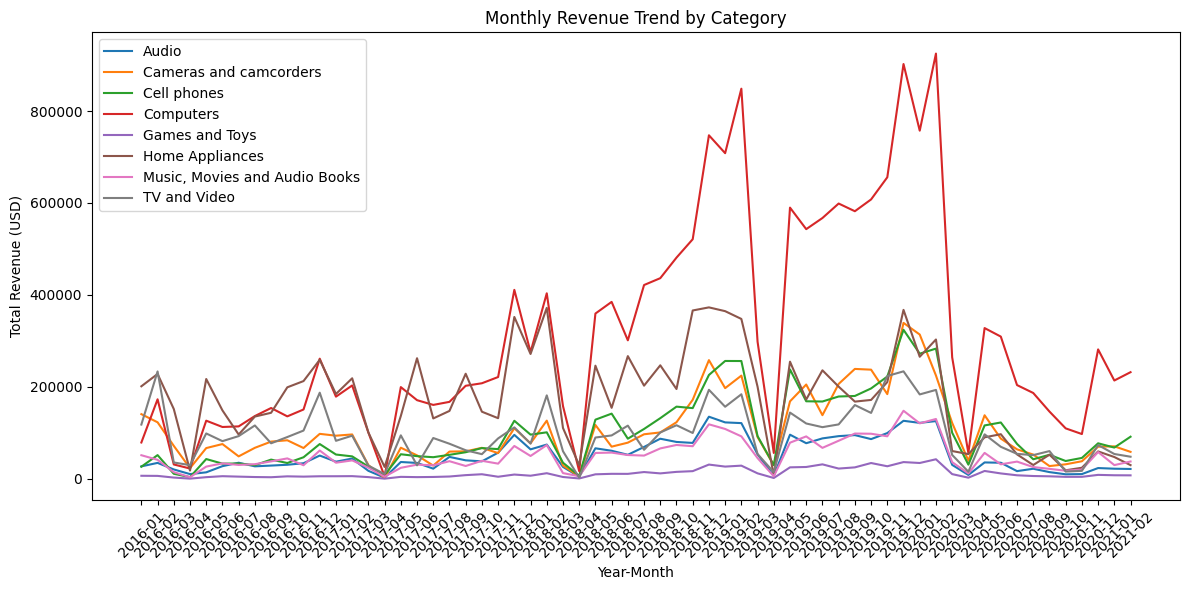

In [31]:
# membuat pivot data
pivot_df = revenue_profit_ym.pivot(
    index='year_month',
    columns='category',
    values='revenue'
)

# mengurutkan berdasarkan waktu (ascending)
pivot_df = pivot_df.sort_index()

plt.figure(figsize=(12,6))

for col in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[col], label=col)

plt.title('Monthly Revenue Trend by Category')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Which sales channel contributes most effectively to overall performance?

In [90]:
channel = pd.read_sql("""
SELECT COUNT(DISTINCT c.customer_key) AS total_customer,  COUNT(DISTINCT s.order_number) AS total_order,
CASE
  WHEN st.store_key = 0 THEN 'Online'
  ELSE 'Offline'
END AS store_type
FROM sales s
JOIN stores st ON s.store_key = st.store_key
JOIN customers c ON s.customer_key = c.customer_key
GROUP BY store_type
""", conn)
channel

,total_customer,total_order,store_type
0,10657,20746,Offline
1,4547,5580,Online


In [84]:
cek = pd.read_sql("""
SELECT COUNT(DISTINCT s.order_number) AS total_order, COUNT(DISTINCT s.customer_key) AS total_customer, c.country,
CASE
  WHEN st.store_key = 0 THEN 'Online'
  ELSE 'Offline'
END AS store_type
FROM sales s
JOIN stores st ON s.store_key = st.store_key
JOIN customers c ON s.customer_key = c.customer_key
GROUP BY store_type, c.country
ORDER BY total_order DESC
""", conn)
cek

,total_order,total_customer,country,store_type
0,11153,5179,United States,Offline
1,3068,2409,United States,Online
2,2784,1424,United Kingdom,Offline
3,1902,1008,Germany,Offline
4,1769,1042,Canada,Offline
5,901,657,Australia,Offline
6,890,475,Italy,Offline
7,776,483,Netherlands,Offline
8,637,545,United Kingdom,Online
9,571,389,France,Offline


In [103]:
cek3 = pd.read_sql("""
SELECT
  CASE
    WHEN st.store_key = 0 THEN 'Online'
    ELSE 'Offline'
  END AS store_type,
  COUNT(DISTINCT s.order_number) AS total_orders,
  SUM(s.quantity * p.unit_price_usd) AS total_revenue,
  ROUND(SUM(s.quantity * p.unit_price_usd)/COUNT(DISTINCT s.order_number),2) AS AOV
FROM sales s
JOIN stores st ON s.store_key = st.store_key
JOIN products p ON s.product_key = p.product_key
GROUP BY store_type
ORDER BY total_revenue DESC;
""", conn)
cek3

,store_type,total_orders,total_revenue,AOV
0,Offline,20746,4.435115e+07,2137.82
1,Online,5580,1.140432e+07,2043.79


In [113]:
cek4 = pd.read_sql("""
WITH customer_channel AS (
  SELECT
    c.customer_key,
    MAX(CASE WHEN st.store_key = 0 THEN 1 ELSE 0 END) AS online_flag,
    MAX(CASE WHEN st.store_key != 0 THEN 1 ELSE 0 END) AS offline_flag
  FROM sales s
  JOIN stores st ON s.store_key = st.store_key
  JOIN customers c ON s.customer_key = c.customer_key
  GROUP BY c.customer_key
),
customer_type AS (
  SELECT
    customer_key,
    CASE
      WHEN online_flag = 1 AND offline_flag = 1 THEN 'Omnichannel'
      WHEN online_flag = 1 AND offline_flag = 0 THEN 'Online Only'
      WHEN online_flag = 0 AND offline_flag = 1 THEN 'Offline Only'
    END AS channel_type
  FROM customer_channel
)

SELECT
  ct.channel_type,
  COUNT(DISTINCT s.order_number) AS total_orders,
  SUM(s.quantity * p.unit_price_usd) AS total_revenue,
  ROUND(SUM(s.quantity * p.unit_price_usd)/COUNT(DISTINCT s.order_number),2) AS AOV
FROM sales s
JOIN customer_type ct ON s.customer_key = ct.customer_key
JOIN products p ON s.product_key = p.product_key
GROUP BY ct.channel_type
ORDER BY total_revenue DESC;
""", conn)
cek4

,channel_type,total_orders,total_revenue,AOV
0,Offline Only,13668,2.949584e+07,2158.02
1,Omnichannel,11168,2.329597e+07,2085.96
2,Online Only,1490,2.963667e+06,1989.04


In [104]:
cek3["total_revenue"] = cek3["total_revenue"].apply(lambda x: f"${x:,.2f}")
cek3

,store_type,total_orders,total_revenue,AOV
0,Offline,20746,"$44,351,154.96",2137.82
1,Online,5580,"$11,404,324.63",2043.79


In [102]:
cek4["total_revenue"] = cek4["total_revenue"].apply(lambda x: f"${x:,.2f}")
cek4

,channel_type,total_orders,total_revenue,AOV
0,Offline Only,13668,"$29,495,841.51",2158.02
1,Omnichannel,11168,"$23,295,970.75",2085.96
2,Online Only,1490,"$2,963,667.33",1989.04


How are customers and sales distributed?

In [33]:
#  sebaran usia pelanggan
pd.read_sql("""
WITH age_category AS(
   SELECT
    CASE
      WHEN age BETWEEN 12 AND 17 THEN '12-17'
      WHEN age BETWEEN 18 AND 25 THEN '18-25'
      WHEN age BETWEEN 26 AND 40 THEN '26-40'
      WHEN age BETWEEN 41 AND 60 THEN '41-60'
      WHEN age >= 61 THEN '> 60'
      ELSE 'Under Age'
    END AS age_group
  FROM (
    SELECT
      CAST((julianday(s.order_date) - julianday(c.birthday)) / 365.25 AS INT) AS age
    FROM sales s
    JOIN customers c ON s.customer_key = c.customer_key
))
SELECT
  age_group,
  COUNT(*) AS total_orders
FROM age_category
GROUP BY age_group
ORDER BY total_orders DESC;
""", conn)

,age_group,total_orders
0,> 60,21230
1,41-60,18493
2,26-40,14132
3,18-25,7694
4,12-17,1335


In [34]:
#  sebaran usia pelanggan
age_dist = pd.read_sql("""
WITH base_data AS (
  SELECT
    s.customer_key, s.quantity, p.unit_price_usd,
    (s.quantity * p.unit_price_usd) AS revenue,
    CAST((julianday(s.order_date) - julianday(c.birthday)) / 365.25 AS INT) AS age
  FROM sales s
  JOIN customers c ON s.customer_key = c.customer_key
  JOIN products p ON s.product_key = p.product_key
),

age_category AS (
  SELECT
    CASE
      WHEN age BETWEEN 12 AND 17 THEN '12-17'
      WHEN age BETWEEN 18 AND 25 THEN '18-25'
      WHEN age BETWEEN 26 AND 40 THEN '26-40'
      WHEN age BETWEEN 41 AND 60 THEN '41-60'
      ELSE '>60'
    END AS age_group,
    revenue, customer_key
  FROM base_data
)

SELECT
  age_group, COUNT(*) AS total_orders, COUNT(DISTINCT customer_key) AS total_customers,
  SUM(revenue) AS total_revenue,
  ROUND( SUM(revenue) * 100.0 / SUM(SUM(revenue)) OVER (),2) AS revenue_percentage
FROM age_category
GROUP BY age_group
ORDER BY total_revenue DESC;
""", conn)
age_dist

,age_group,total_orders,total_customers,total_revenue,revenue_percentage
0,>60,21230,4100,1.885498e+07,33.82
1,41-60,18493,3733,1.629680e+07,29.23
2,26-40,14132,2893,1.260569e+07,22.61
3,18-25,7694,1626,6.797117e+06,12.19
4,12-17,1335,351,1.200890e+06,2.15


In [35]:
age_dist["total_revenue"] = age_dist["total_revenue"].apply(lambda x: f"${x:,.2f}")
age_dist

,age_group,total_orders,total_customers,total_revenue,revenue_percentage
0,>60,21230,4100,"$18,854,982.28",33.82
1,41-60,18493,3733,"$16,296,800.95",29.23
2,26-40,14132,2893,"$12,605,688.64",22.61
3,18-25,7694,1626,"$6,797,117.30",12.19
4,12-17,1335,351,"$1,200,890.42",2.15


In [59]:
# berdasarkan lokasi
cust_by_loc = pd.read_sql("""
SELECT
  c.country,
  COUNT(DISTINCT s.customer_key)
FROM sales s
JOIN customers c ON s.customer_key = c.customer_key
GROUP BY c.country
ORDER BY COUNT(DISTINCT s.customer_key) DESC
""", conn)
cust_by_loc

,country,COUNT(DISTINCT s.customer_key)
0,United States,5706
1,United Kingdom,1570
2,Canada,1179
3,Germany,1150
4,Australia,780
5,Netherlands,534
6,Italy,530
7,France,438


In [118]:
cust_active = pd.read_sql('''
SELECT
  c.country, COUNT(DISTINCT s.order_number) AS total_orders,
  COUNT(DISTINCT s.customer_key) AS total_customers,
  ROUND(
    COUNT(DISTINCT s.customer_key) * 100.0 /
    COUNT(DISTINCT c.customer_key),
    2
  ) AS cust_active_percentage
FROM customers c
LEFT JOIN sales s
  ON c.customer_key = s.customer_key
GROUP BY c.country
ORDER BY cust_active_percentage DESC;
''',conn)
cust_active

,country,total_orders,total_customers,cust_active_percentage
0,United States,14221,5706,83.57
1,Italy,1101,530,82.17
2,United Kingdom,3421,1570,80.76
3,Germany,2440,1150,78.07
4,Canada,2281,1179,75.92
5,Netherlands,976,534,72.85
6,France,704,438,65.37
7,Australia,1182,780,54.93


In [117]:
aov_by_country = pd.read_sql('''
SELECT
  c.country,
  COUNT(DISTINCT c.customer_key) AS total_customers,
  COUNT(DISTINCT s.customer_key) AS active_customers,
  COUNT(DISTINCT s.order_number) AS total_orders,
  ROUND(SUM(s.quantity * p.unit_price_usd), 2) AS total_revenue,
  ROUND(
    COUNT(DISTINCT s.customer_key) * 100.0 /
    COUNT(DISTINCT c.customer_key),
    2
  ) AS cust_active_percentage,
  ROUND(
    SUM(s.quantity * p.unit_price_usd) /
    COUNT(DISTINCT s.order_number),
    2
  ) AS AOV
FROM customers c
LEFT JOIN sales s
  ON c.customer_key = s.customer_key
LEFT JOIN products p
  ON s.product_key = p.product_key
GROUP BY c.country
ORDER BY AOV DESC;
''',conn)
aov_by_country

,country,total_customers,active_customers,total_orders,total_revenue,cust_active_percentage,AOV
0,Australia,1420,780,1182,2708137.61,54.93,2291.15
1,Italy,645,530,1101,2475645.77,82.17,2248.54
2,Germany,1473,1150,2440,5414149.80,78.07,2218.91
3,France,670,438,704,1515338.22,65.37,2152.47
4,United States,6828,5706,14221,29871631.17,83.57,2100.53
5,Canada,1553,1179,2281,4724334.63,75.92,2071.17
6,United Kingdom,1944,1570,3421,7084088.12,80.76,2070.77
7,Netherlands,733,534,976,1962154.27,72.85,2010.40


In [116]:
aov_by_continent = pd.read_sql('''
SELECT
  c.continent,
  COUNT(DISTINCT c.customer_key) AS total_customers,
  COUNT(DISTINCT s.customer_key) AS active_customers,
  COUNT(DISTINCT s.order_number) AS total_orders,
  ROUND(SUM(s.quantity * p.unit_price_usd), 2) AS total_revenue,
  ROUND(
    COUNT(DISTINCT s.customer_key) * 100.0 /
    COUNT(DISTINCT c.customer_key),
    2
  ) AS cust_active_percentage,
  ROUND(
    SUM(s.quantity * p.unit_price_usd) * 1.0 /
    NULLIF(COUNT(DISTINCT s.order_number), 0),
    2
  ) AS AOV
FROM customers c
LEFT JOIN sales s
  ON c.customer_key = s.customer_key
LEFT JOIN products p
  ON s.product_key = p.product_key
GROUP BY c.continent
ORDER BY AOV DESC;
''',conn)
aov_by_continent

,continent,total_customers,active_customers,total_orders,total_revenue,cust_active_percentage,AOV
0,Australia,1420,780,1182,2708137.61,54.93,2291.15
1,Europe,5465,4222,8642,18451376.18,77.26,2135.08
2,North America,8381,6885,16502,34595965.80,82.15,2096.47
